In [1]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,roc_auc_score,roc_curve,balanced_accuracy_score
import matplotlib.pyplot as plt

In [2]:
df=sns.load_dataset('titanic')

In [3]:
print('*'*60)
print(df.info())
print('*'*60)
print(df.describe())
print('*'*60)
print(df.shape)
print('*'*60)

#################################################################################

#missing values percenatage

print('Before filling missing values')
for column in df.columns:
  missing_percentage=(df[column].isna().sum()/len(df[column]))*100
  if missing_percentage:
    print(f'{column} Column has  {missing_percentage:.2f}% missing values')
print('*'*60)

#################################################################################

df.to_csv('titanic.csv',index=False)

#################################################################################

#missing value handling

#deck column has 77% missing values, dropping the column would be ideal here, as imputating this column, wouldn't help gain anything.
df_new=df.drop(columns='deck')

#filling missing value in age column with median as mean would give decimal numbers, seeing age with decimal numbers wouldn't be ideal.
df_new['age']=df_new['age'].fillna(df['age'].median())

#filling embarked,embark_town columns with mode, as these are categorical columns, filling missing values with frequently occuring value would make sense.
df_new['embarked']=df_new['embarked'].fillna(df_new['embarked'].mode()[0])
df_new['embark_town']=df_new['embark_town'].fillna(df_new['embark_town'].mode()[0])

#################################################################################

print('After filling values')
for column in df_new.columns:
  missing_percentage=(df_new[column].isna().sum()/len(df_new[column]))*100
  if missing_percentage:
    print(f'{column} Column has  {missing_percentage:.2f}% missing values')
else:
  print(f'There are no columns with missing values now..')

************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
*************

************************************************************************************************************************


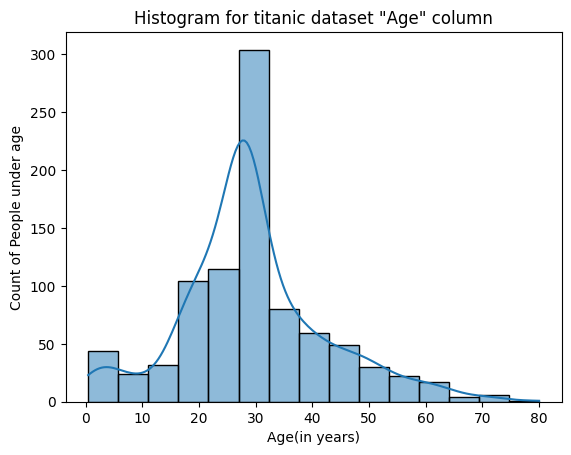

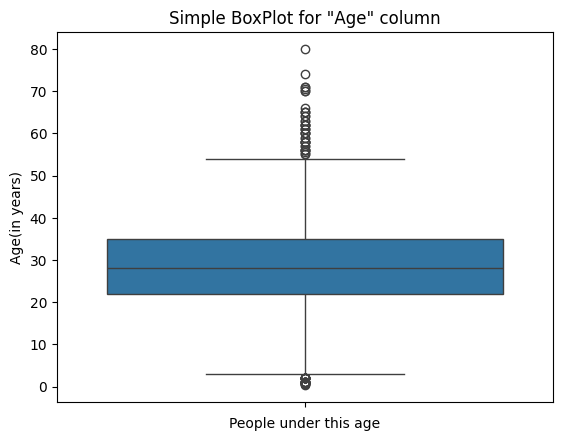

************************************************************************************************************************


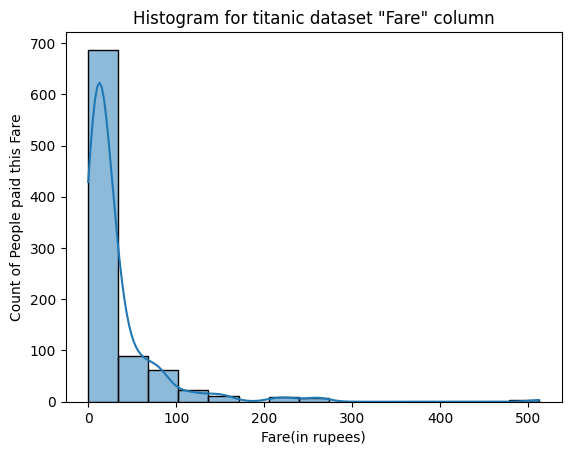

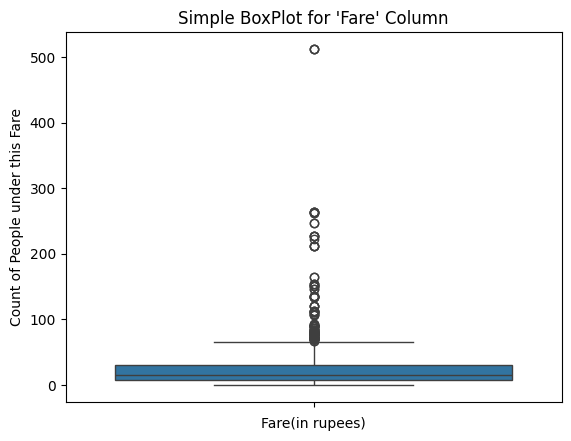

************************************************************************************************************************
Number of outliers for age is 66
Number of outliers for fare is 156
************************************************************************************************************************
Mean:32.204207968574636, Median:14.4542, Mode:8.05
Fare column is right skewed

Using skew method to find skewness for fare
Skew is 4.787316519674893
Fare is right skewed
************************************************************************************************************************


In [4]:
#Univariate analysis:

print('*'*120)
#historgram for age column
sns.histplot(df_new,x='age',kde=True,bins=15)
plt.title('Histogram for titanic dataset "Age" column')
plt.xlabel('Age(in years)')
plt.ylabel('Count of People under age')
plt.show()

#boxplot for age column
sns.boxplot(df_new,y='age')
plt.title('Simple BoxPlot for "Age" column')
plt.xlabel('People under this age')
plt.ylabel('Age(in years)')
plt.show()

print('*'*120)
#histogram for fare column
sns.histplot(df_new,x='fare',bins=15,kde=True)
plt.title('Histogram for titanic dataset "Fare" column')
plt.xlabel("Fare(in rupees)")
plt.ylabel("Count of People paid this Fare")
plt.show()

#Boxplot for fare column
sns.boxplot(df_new,y='fare')
plt.title("Simple BoxPlot for 'Fare' Column")
plt.xlabel('Fare(in rupees)')
plt.ylabel('Count of People under this Fare')
plt.show()

print('*'*120)
#Outliers for age,fare columns

q1=df_new['age'].quantile(0.25)
q3=df_new['age'].quantile(0.75)
IQR=q3-q1

lower_bound=q1 - 1.5*IQR
upper_bound=q3 + 1.5*IQR

for column in ['age','fare']:
  mask=(df_new[column]<lower_bound) | (df_new[column]>upper_bound)
  print(f'Number of outliers for {column} is {len(df[mask])}')

#################################################################################
print('*'*120)
mean=df_new['fare'].mean()
median=df_new['fare'].median()
mode=df_new['fare'].mode()[0]

print(f'Mean:{mean}, Median:{median}, Mode:{mode}')
if mean > median and median > mode:
  print('Fare column is right skewed')
elif mean < median and median < mode:
  print('Fare column in left skewed')
else:
  print('Fare column is symmetric i.e. mean=mode=median')
print()
print('Using skew method to find skewness for fare')
skew=df['fare'].skew()
print(f'Skew is {skew}')
if skew>0.5:
  print('Fare is right skewed')
elif skew<0.5:
  print('Fare is left skewed')
else:
  print('Fare is symmetric')
print('*'*120)
#################################################################################

******************** Survival Rate by Sex ********************
Men"s survival rate is 18.89%
Female"s survival rate is 74.20%
******************** Survival Rate by pclass ********************
Survived rate for plcass1 is 62.96%
Survived rate for plcass2 is 47.28%
Survived rate for plcass3 is 24.24%
******************** Survival Rate by both sex,pclass ********************
Survival rate for sex male and pclass1 is 36.89%
Survival rate for sex male and pclass2 is 15.74%
Survival rate for sex male and pclass3 is 13.54%
Survival rate for sex female and pclass1 is 96.81%
Survival rate for sex female and pclass2 is 92.11%
Survival rate for sex female and pclass3 is 50.00%


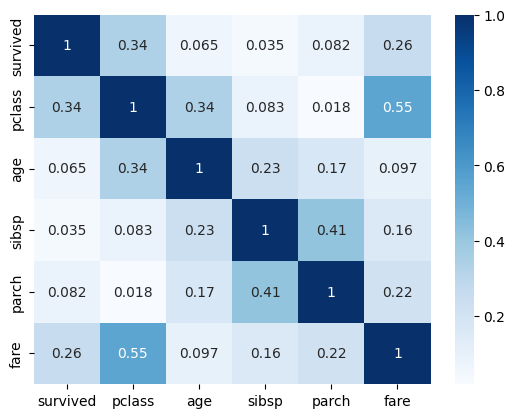

In [5]:
#################################################################################
#Bivariate Analysis:

# df_new.groupby('sex')['survived'].mean().reset_index()
# df_new.groupby('pclass')['survived'].mean().reset_index()
# df_new.groupby(['pclass','sex'])['survived'].mean().reset_index()

rate_survived=df_new['survived']==1

#Survival rate by sex
print('*'*20,'Survival Rate by Sex', '*'*20)
rate_male=df_new['sex']=='male'
rate_female=df_new['sex']=='female'

survived_male=len(df_new[(rate_survived)&(rate_male)])/len(df[rate_male])
print(f'Men"s survival rate is {survived_male*100:.2f}%')

survived_female=len(df[(rate_survived)&(rate_female)])/len(df[rate_female])
print(f'Female"s survival rate is {survived_female*100:.2f}%')

#Survival rate by pclass
print('*'*20,'Survival Rate by pclass', '*'*20)
rate_pclass1=df_new['pclass']==1
rate_pclass2=df_new['pclass']==2
rate_pclass3=df_new['pclass']==3

survived_pclass1=len(df[(rate_survived)&(rate_pclass1)])/len(df[rate_pclass1])
print(f'Survived rate for plcass1 is {survived_pclass1*100:.2f}%')
survived_pclass2=len(df[(rate_survived)&(rate_pclass2)])/len(df[rate_pclass2])
print(f'Survived rate for plcass2 is {survived_pclass2*100:.2f}%')
survived_pclass3=len(df[(rate_survived)&(rate_pclass3)])/len(df[rate_pclass3])
print(f'Survived rate for plcass3 is {survived_pclass3*100:.2f}%')


#survival rate by both sex,pclass.
print('*'*20,'Survival Rate by both sex,pclass', '*'*20)
survived_male_pclass1=len(df[(rate_male)&(rate_pclass1)&(rate_survived)])/len(df[(rate_male)&(rate_pclass1)])
print(f'Survival rate for sex male and pclass1 is {survived_male_pclass1*100:.2f}%')
survived_male_pclass2=len(df[(rate_male)&(rate_pclass2)&(rate_survived)])/len(df[(rate_male)&(rate_pclass2)])
print(f'Survival rate for sex male and pclass2 is {survived_male_pclass2*100:.2f}%')
survived_male_pclass3=len(df[(rate_male)&(rate_pclass3)&(rate_survived)])/len(df[(rate_male)&(rate_pclass3)])
print(f'Survival rate for sex male and pclass3 is {survived_male_pclass3*100:.2f}%')


survived_female_pclass1=len(df[(rate_female)&(rate_pclass1)&(rate_survived)])/len(df[(rate_female)&(rate_pclass1)])
print(f'Survival rate for sex female and pclass1 is {survived_female_pclass1*100:.2f}%')
survived_female_pclass2=len(df[(rate_female)&(rate_pclass2)&(rate_survived)])/len(df[(rate_female)&(rate_pclass2)])
print(f'Survival rate for sex female and pclass2 is {survived_female_pclass2*100:.2f}%')
survived_female_pclass3=len(df[(rate_female)&(rate_pclass3)&(rate_survived)])/len(df[(rate_female)&(rate_pclass3)])
print(f'Survival rate for sex female and pclass3 is {survived_female_pclass3*100:.2f}%')


corr_columns=['survived', 'pclass','age','sibsp','parch','fare']

df_new[corr_columns].corr()
df_corr=df_new[corr_columns]

sns.heatmap(df_corr.corr().abs(),annot=True, cmap='Blues')
plt.show()

#Strongest correlations
#1 - pclass vs fare. Passenger Class vs Fare directly related, i.e passengers who pay more fare are obvious to get high coach/pclass.
#2 - sibsp vs parch. parch (Parents/Children), sibsp(Siblings/Spouse). Passengers who travelled with parents/children are high likely to also travel with siblings or spouse.
#################################################################################

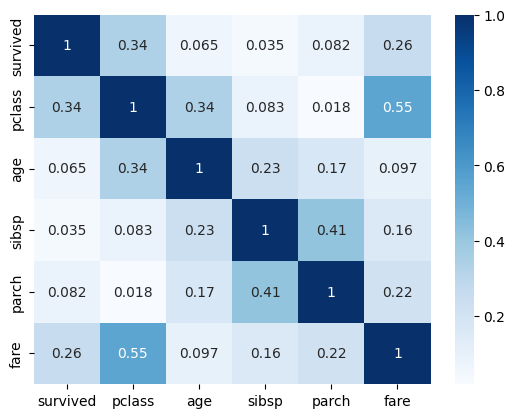

In [6]:
corr_columns=['survived', 'pclass','age','sibsp','parch','fare']

df_new[corr_columns].corr()
df_corr=df_new[corr_columns]

sns.heatmap(df_corr.corr().abs(),annot=True, cmap='Blues')
plt.show()

#Strongest correlations
#1 - pclass vs fare. Passenger Class vs Fare directly related, i.e passengers who pay more fare are obvious to get high coach/pclass.
#2 - sibsp vs parch. parch (Parents/Children), sibsp(Siblings/Spouse). Passengers who travelled with parents/children are high likely to also travel with siblings or spouse.

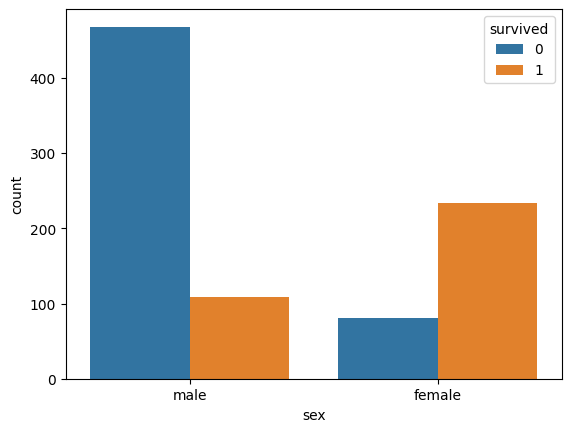

In [9]:
sns.countplot(df_new, x='sex', hue='survived')
plt.show()

In [10]:
df_new['sex'].value_counts()

,count
sex,
male,577
female,314
